In [3]:
import numpy as np
import matplotlib.pyplot as plt
import meanderpy as mp

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 500

In [18]:
SECONDS_PER_YEAR = 365.25 * 24 * 3600
NIT = 1001
W = 100.0
MAG = 1e-5

EXTENT = (0, 1000, -2500, 2500)

KL_M_PER_YR = 100.0       
CRDIST = 1*W


KV_M_PER_YR = 3.16e-5    
DT_YEARS = 0.1         

kl = KL_M_PER_YR / SECONDS_PER_YEAR
kv = KV_M_PER_YR / SECONDS_PER_YEAR
dt = DT_YEARS * SECONDS_PER_YEAR

def run_sim(pert, crdist):
    theta0 = 1.5
    n_nodes = 1000
    total_length = 10000.0
    lamb = 500.0
    base_angle = 0.0

    s = np.linspace(0.0, total_length, n_nodes)
    theta = theta0 * np.sin(2.0 * np.pi * s / lamb) + base_angle

    x = np.zeros_like(s)
    y = np.zeros_like(s)
    for i in range(1, n_nodes):
        ds = s[i] - s[i-1]
        x[i] = x[i-1] + ds * np.cos(theta[i])
        y[i] = y[i-1] + ds * np.sin(theta[i])

    if pert != 0.0:
        mid = len(x) // 2
        y[mid] += pert

    z = np.zeros_like(x)
    ch = mp.Channel(x, y, z, W, 1.0)
    chb = mp.ChannelBelt([ch], [], [0.0], [])

    saved_ts = 1
    deltas = 50.0
    pad = 0
    depths = np.ones(NIT)
    Cfs = 0.0065 * np.ones(NIT)
    dens = 1000
    t1 = t2 = t3 = 0
    aggr_factor = 0.0

    chb.migrate(
        NIT, saved_ts, deltas, pad, crdist,
        depths, Cfs,
        kl, kv, dt,
        dens, t1, t2, t3, aggr_factor
    )
    return chb

chb_ref  = run_sim(0.0, CRDIST)
chb_pert = run_sim(MAG, CRDIST)

100%|██████████| 1001/1001 [00:01<00:00, 698.51it/s]


In [5]:
def get_log_diff(ch1, ch2, cell_size):
    if ch1 is None or ch2 is None:
        return np.nan

    x_all = np.concatenate([ch1.x, ch2.x])
    y_all = np.concatenate([ch1.y, ch2.y])

    xmin = x_all.min()
    xmax = x_all.max()
    ymin = y_all.min()
    ymax = y_all.max()

    xmin_snap = np.floor(xmin / cell_size) * cell_size
    xmax_snap = np.ceil(xmax / cell_size) * cell_size
    ymin_snap = np.floor(ymin / cell_size) * cell_size
    ymax_snap = np.ceil(ymax / cell_size) * cell_size

    cols = int((xmax_snap - xmin_snap) / cell_size)
    rows = int((ymax_snap - ymin_snap) / cell_size)

    def raster(c):
        g = np.zeros((rows, cols), dtype=bool)
        xs = np.linspace(c.x[:-1], c.x[1:], 10)
        ys = np.linspace(c.y[:-1], c.y[1:], 10)
        col_idx = ((xs - xmin_snap) / cell_size).astype(int)
        row_idx = ((ys - ymin_snap) / cell_size).astype(int)
        mask = (0 <= col_idx) & (col_idx < cols) & (0 <= row_idx) & (row_idx < rows)
        g[row_idx[mask], col_idx[mask]] = True
        return g.astype(int)

    g1 = raster(ch1)
    g2 = raster(ch2)

    # pure Hamming distance (no square root)
    return_val = np.count_nonzero(g1 != g2)

    return np.log(return_val) if return_val > 0 else np.nan

cell_size = 10.0

# sample every 100 timesteps
step = 1
time_phys = np.arange(NIT) * DT_YEARS
indices = np.arange(0, NIT, step)

log_norms = np.array([
    get_log_diff(chb_ref.channels[t], chb_pert.channels[t], cell_size=cell_size)
    for t in indices
])

mask = np.isfinite(log_norms)
t_data = time_phys[indices][mask]   # still in YEARS
y_data = log_norms[mask]

In [6]:
def get_log_diff(ch1, ch2, cell_size):
    if ch1 is None or ch2 is None:
        return np.nan

    x_all = np.concatenate([ch1.x, ch2.x])
    y_all = np.concatenate([ch1.y, ch2.y])

    xmin = x_all.min()
    xmax = x_all.max()
    ymin = y_all.min()
    ymax = y_all.max()

    xmin_snap = np.floor(xmin / cell_size) * cell_size
    xmax_snap = np.ceil(xmax / cell_size) * cell_size
    ymin_snap = np.floor(ymin / cell_size) * cell_size
    ymax_snap = np.ceil(ymax / cell_size) * cell_size

    cols = int((xmax_snap - xmin_snap) / cell_size)
    rows = int((ymax_snap - ymin_snap) / cell_size)

    def raster(c):
        g = np.zeros((rows, cols), dtype=bool)
        xs = np.linspace(c.x[:-1], c.x[1:], 10)
        ys = np.linspace(c.y[:-1], c.y[1:], 10)
        col_idx = ((xs - xmin_snap) / cell_size).astype(int)
        row_idx = ((ys - ymin_snap) / cell_size).astype(int)
        mask = (0 <= col_idx) & (col_idx < cols) & (0 <= row_idx) & (row_idx < rows)
        g[row_idx[mask], col_idx[mask]] = True
        return g.astype(int)

    g1 = raster(ch1)
    g2 = raster(ch2)

    # pure Hamming distance (no square root)
    return_val = np.count_nonzero(g1 != g2)

    return np.log(return_val) if return_val > 0 else np.nan

cell_size = 10.0

# sample every 100 timesteps
step = 1
time_phys = np.arange(NIT) * DT_YEARS
indices = np.arange(0, NIT, step)

log_norms = np.array([
    get_log_diff(chb_ref.channels[t], chb_pert.channels[t], cell_size=cell_size)
    for t in indices
])

mask = np.isfinite(log_norms)
t_data = time_phys[indices][mask]   # still in YEARS
y_data = log_norms[mask]

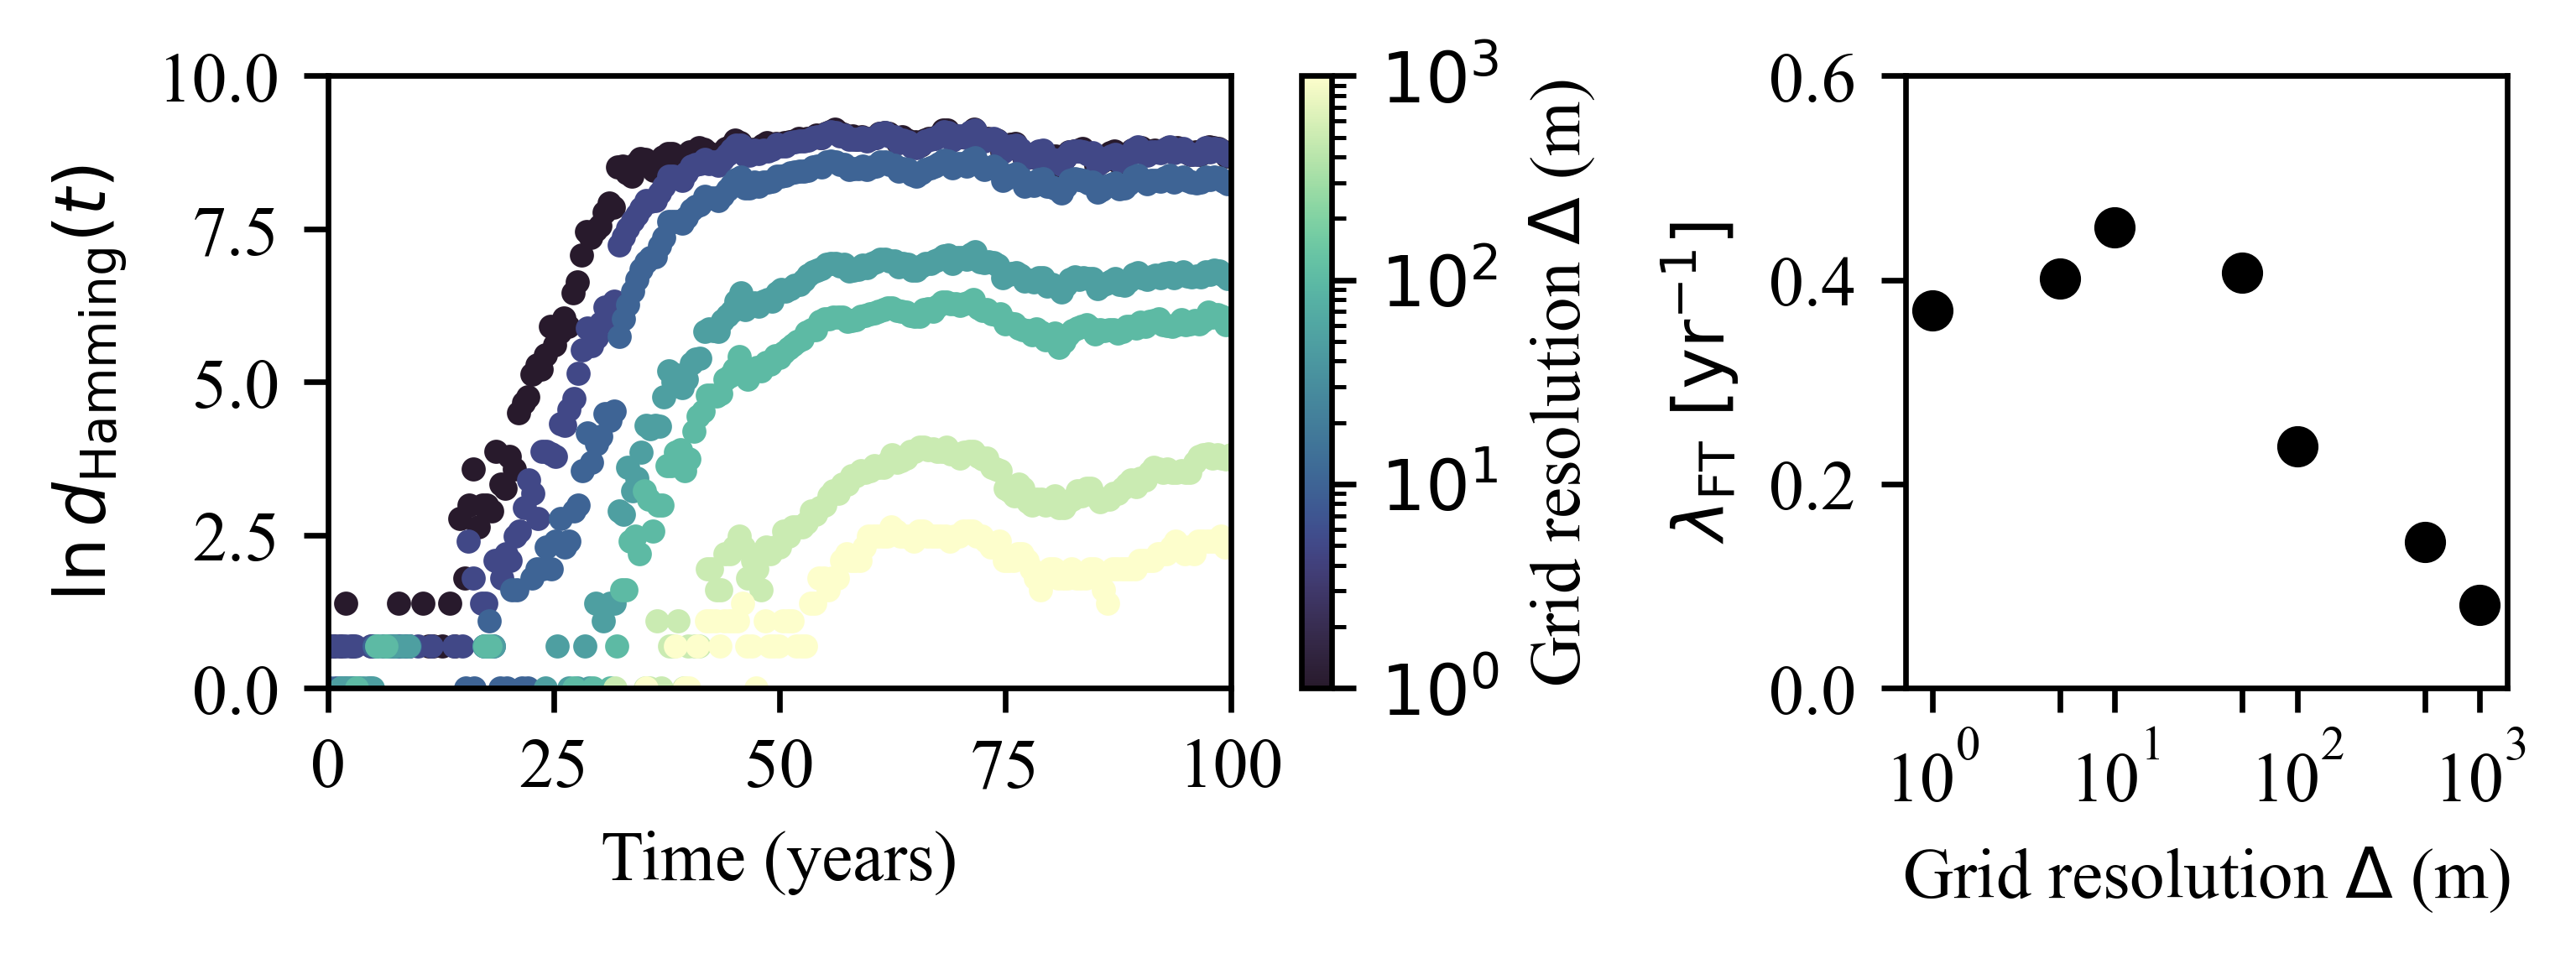

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext, FixedLocator
from matplotlib.cm import ScalarMappable

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.dpi"] = 600

# ---------------------------------------------
# Scatter data (right panel)
# ---------------------------------------------
cell_sizes_all = np.array([1, 5, 10, 50, 100, 500, 1000], dtype=float)
growth_rates   = np.array([0.37043, 0.40124, 0.4515, 0.40708,
                           0.2371, 0.14285, 0.08134], dtype=float)

# ---------------------------------------------
# Time-series Δ’s (left panel)
# ---------------------------------------------
cell_sizes_time = [1, 5, 10, 50, 100, 500, 1000]

step = 1
time_phys = np.arange(NIT) * DT_YEARS
indices = np.arange(0, NIT, step)

fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(5, 1.8),
    gridspec_kw={'width_ratios': [1.5,1], 'wspace': 0.05},
    constrained_layout=True
)

# ---------------------------------------------
# Colormap + normalizer for Δ range
# ---------------------------------------------
cmap = cmocean.cm.deep_r
norm = LogNorm(vmin=min(cell_sizes_time), vmax=max(cell_sizes_time))
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# =====================================================
# LEFT PANEL: log Hamming distance vs *years*
# =====================================================
for cell_size in cell_sizes_time:
    log_vals = np.array([
        get_log_diff(chb_ref.channels[t], chb_pert.channels[t], cell_size)
        for t in indices
    ])

    mask = np.isfinite(log_vals)
    t_data = time_phys[indices][mask]
    y_data = log_vals[mask]

    if len(t_data) == 0:
        continue

    color = cmap(norm(cell_size))
    ax_left.scatter(t_data[::5], y_data[::5], color=color, s=6.0,
                 label=fr'$\Delta = {cell_size}\,$m')

ax_left.set_xlabel("Time (years)")
ax_left.set_ylabel(r"$\ln d_{\mathrm{Hamming}}(t)$")
ax_left.set_xlim([0,100])
ax_left.set_ylim([0,10])


# Colorbar for Δ
cbar = fig.colorbar(sm, ax=ax_left, pad=0.02)
cbar.set_label(r'Grid resolution $\Delta$ (m)', labelpad=4)
cb_ticks = [1, 10, 100, 1000]
cbar.set_ticks(cb_ticks)
cbar.ax.set_yticklabels(
    [fr"$10^{{{int(np.log10(t))}}}$" if t in [1,10,100,1000] else f"{t}" for t in cb_ticks]
)

# =====================================================
# RIGHT PANEL: growth-rate scatter for all Δ
# =====================================================
ax_right.scatter(cell_sizes_all, growth_rates, color='k', s=24)
ax_right.set_xscale('log')
ax_right.set_xlabel(r'Grid resolution $\Delta$ (m)')
ax_right.set_ylabel(r"$\lambda_{\mathrm{FT}}\ \mathrm{[yr^{-1}]}$")
ax_right.set_ylim([0,0.6])
#ax_right.set_xlim([1e-1,1e4])
#ax_right.set_xticks([1e-1,1e0, 1e1,1e2,1e3,1e4])

ax_right.xaxis.set_major_locator(FixedLocator(cell_sizes_all))
ax_right.xaxis.set_major_formatter(LogFormatterMathtext())

fig.savefig("/Users/braydennoh/Downloads/resolution.svg", format="svg", bbox_inches="tight")
plt.show()

In [16]:
print(cell_sizes_all)
print(growth_rates)

[   1.    5.   10.   50.  100.  500. 1000.]
[0.37043 0.40124 0.4515  0.40708 0.2371  0.14285 0.08134]


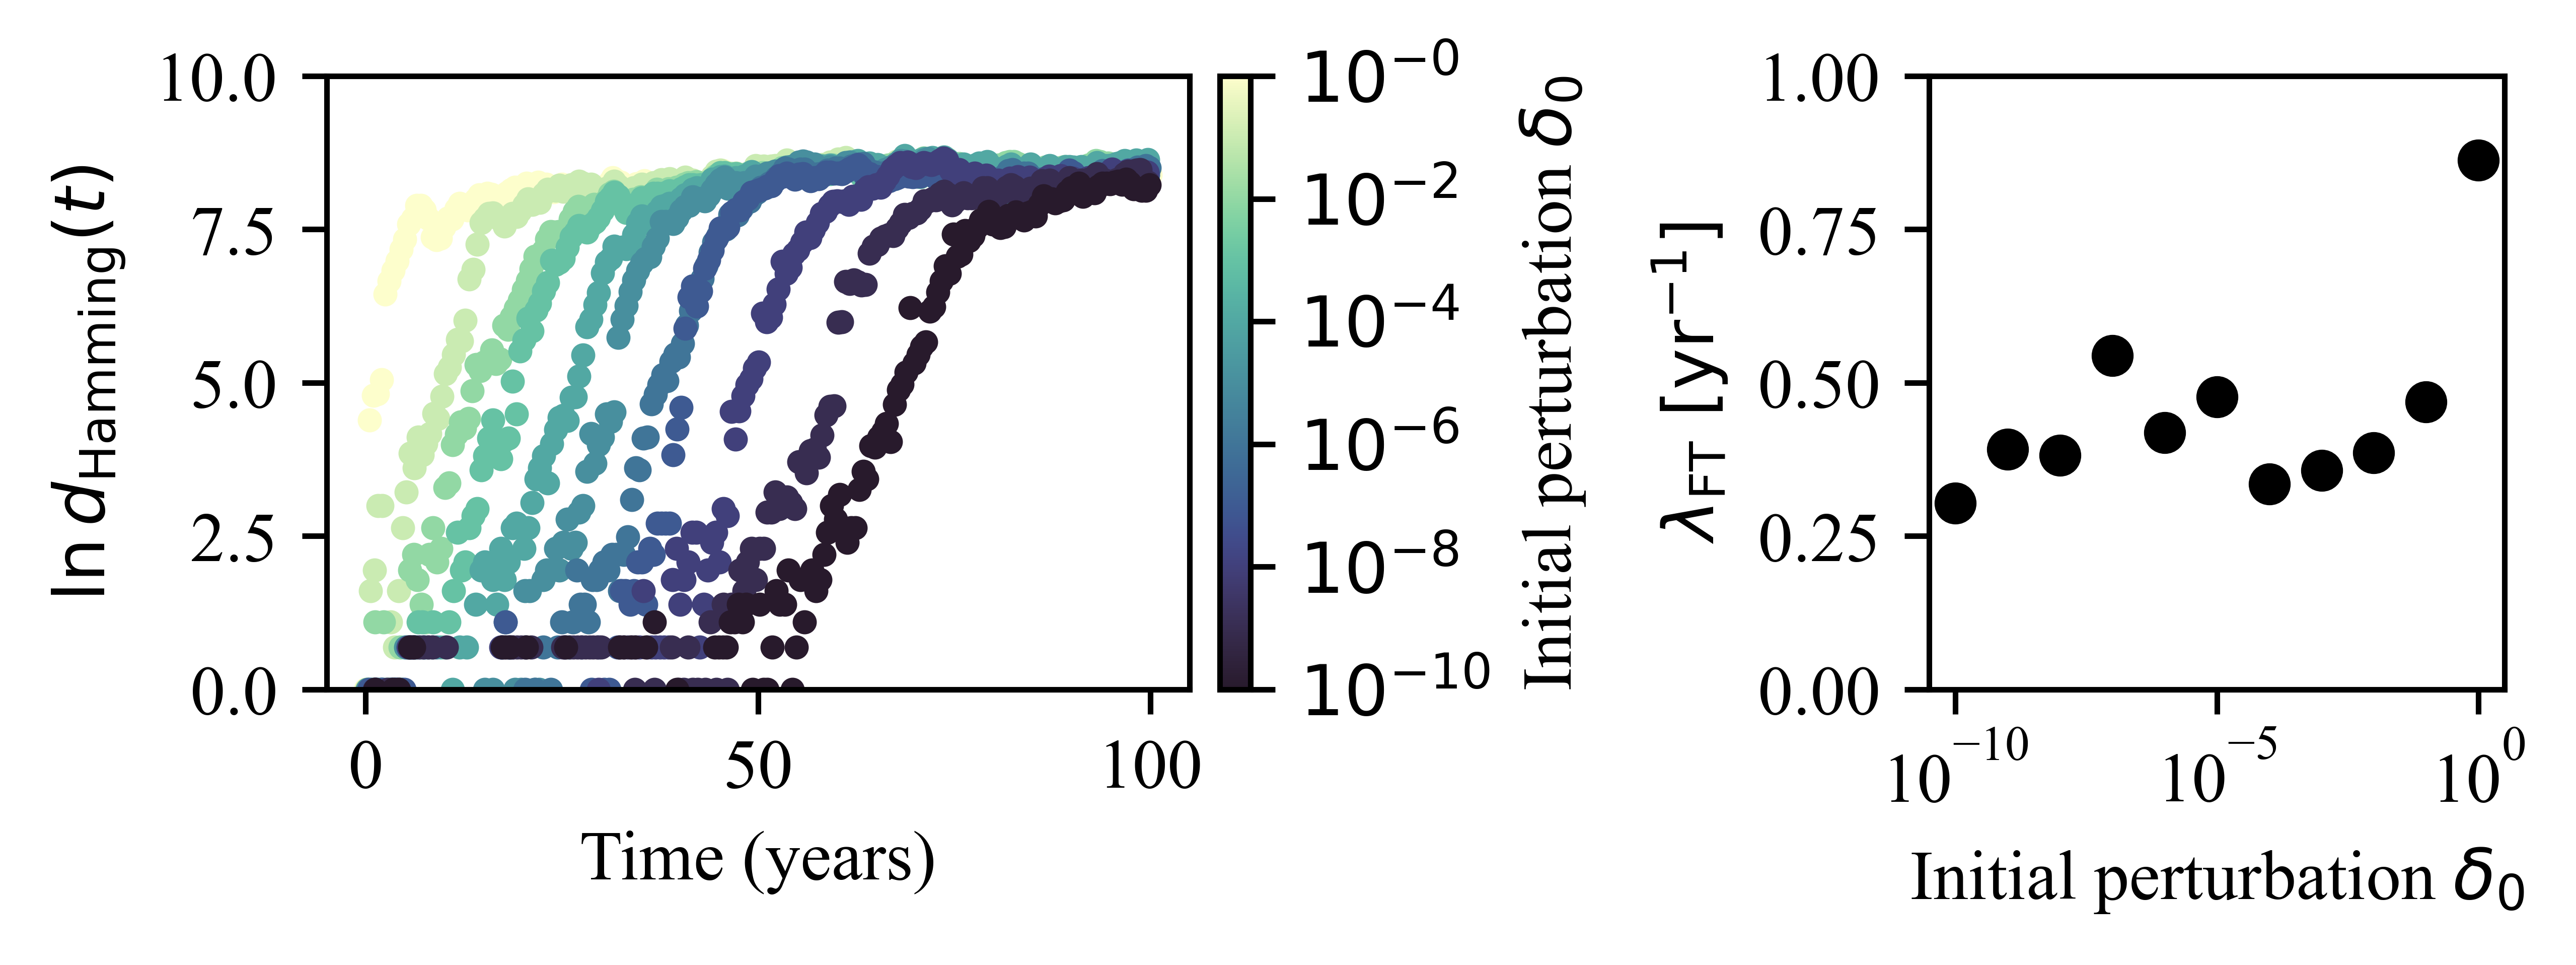

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.dpi"] = 1000

base = "/Users/braydennoh/Research/ChaosRiver/revision1/perturb"

# ---------------------------------------------
# Perturbation magnitudes including 1e0
# ---------------------------------------------
exponents = np.arange(-0, -11, -1, dtype=float)   # 0, -1, -2, ..., -10
deltas    = 10.0 ** exponents                    # 1e0 ... 1e-10

# ---------------------------------------------
# FTLE values for exponents 0 ... -10
# ---------------------------------------------
lambda_ft = np.array([
    0.86315,   # 1e0
    0.46870,   # 1e-1
    0.38622,   # 1e-2
    0.35749,   # 1e-3
    0.33489,   # 1e-4
    0.47712,   # 1e-5
    0.41858,   # 1e-6
    0.54435,   # 1e-7
    0.38174,   # 1e-8
    0.39185,   # 1e-9
    0.30349    # 1e-10
], dtype=float)

fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(5, 1.8),
    gridspec_kw={'width_ratios': [1.5,1], 'wspace': 0.05},
    constrained_layout=True
)

# ------------------------------------------------------
# LEFT PANEL — ln d_Hamming(t) vs time (every 10th point)
# ------------------------------------------------------
cmap = cmocean.cm.deep_r
norm = LogNorm(vmin=deltas.min(), vmax=deltas.max())
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

for d in deltas:
    exp = int(-np.log10(d)) if d < 1 else 0
    label = f"1e-{exp}" if d < 1 else "1e0"
    fname = f"{base}/{label}.txt"

    data = np.loadtxt(fname)
    t_data = data[:, 0]
    y_data = data[:, 1]

    color = cmap(norm(d))
    ax_left.scatter(t_data[::5], y_data[::5], s=6.0, color=color)

ax_left.set_xlabel("Time (years)")
ax_left.set_ylabel(r"$\ln d_{\mathrm{Hamming}}(t)$")
ax_left.set_ylim([0,10])
ax_left.set_yticks([0,2.5,5,7.5,10])

cbar = fig.colorbar(sm, ax=ax_left, pad=0.02)
cbar.set_label(r"Initial perturbation $\delta_0$")
cbar.set_ticks(deltas)
tick_values = [1e0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10]

cbar.set_ticks(tick_values)
cbar.set_ticklabels([
    r"$10^{-0}$",
    r"$10^{-2}$",
    r"$10^{-4}$",
    r"$10^{-6}$",
    r"$10^{-8}$",
    r"$10^{-10}$"
])


# ------------------------------------------------------
# RIGHT PANEL — FTLE vs perturbation size
# ------------------------------------------------------
ax_right.scatter(deltas, lambda_ft, color='k', s=25)
ax_right.set_xscale('log')
ax_right.set_xlabel(r"Initial perturbation $\delta_0$")
ax_right.set_ylabel(r"$\lambda_{\mathrm{FT}}\ \mathrm{[yr^{-1}]}$")
ax_right.set_yticks([0,0.25,0.5,0.75,1])
ax_right.set_xticks([1e-10,1e-5,1e-0])

fig.savefig("/Users/braydennoh/Downloads/perturb.svg", format="svg", bbox_inches="tight")
plt.show()